In [21]:
import pandas as pd
import numpy as np
import plotly as plt
import seaborn as sns
import plotly.express as px

In [22]:
df = pd.read_csv('/Users/anandguntuku/Movies/VSCodeFolder/SarvaniMLOps/Data/merged_df.csv')
df.head(2)

/var/folders/_n/g_d34gh57sb9jndsrxxvvdy40000gn/T/ipykernel_63869/2838547346.py:1: DtypeWarning: Columns (28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/anandguntuku/Movies/VSCodeFolder/SarvaniMLOps/Data/merged_df.csv')


,Outlet,Date_Time,Bill_No,Item_Price,Item_Quantity,Item_Total_Amount,Bill_Item_Count,Order_Type,Weekday,Total_Bill_Amount_Corrected,...,Year,Month,Week_Number,Day,Festivity_y,Quarter,Festivity_Group,Day_Type,DayFestGroup,Holiday_Name
0,MADDILAPALEM OUTLET,2022-04-01 06:54:17.779,2022211,266.6667,1.0,279.9967,1,general,4,280.0,...,2022,4,13,1,regular,Q1,Non-Festive,Wknd,Wknd - Non-Festive,NaN
1,MADDILAPALEM OUTLET,2022-04-01 08:27:52.593,2022212,180.9524,1.0,190.0024,1,general,4,190.0,...,2022,4,13,1,regular,Q1,Non-Festive,Wknd,Wknd - Non-Festive,NaN


In [23]:
df.columns

Index(['Outlet', 'Date_Time', 'Bill_No', 'Item_Price', 'Item_Quantity',
       'Item_Total_Amount', 'Bill_Item_Count', 'Order_Type', 'Weekday',
       'Total_Bill_Amount_Corrected', 'Daily_Bill_Amount',
       'Corrected_Item_Name', 'Portion_Code', 'Corrected_Item_Category',
       'total_weight_kg', 'Festivity_x', 'Bill_Class', 'Date', 'Unnamed: 0',
       'Year', 'Month', 'Week_Number', 'Day', 'Festivity_y', 'Quarter',
       'Festivity_Group', 'Day_Type', 'DayFestGroup', 'Holiday_Name'],
      dtype='object')

In [4]:
df['Bill_Amount'] = df.groupby(['Bill_No','Outlet','Date'])['Item_Total_Amount'].transform('sum').round(0)
df

,Unnamed: 0,Outlet,Date,Bill_No,Item_Name,Item_Category,Item_Price,Item_Quantity,Item_Total_Amount,Daily_Bill_Amount,Total_Weight(Kg),Bill_Item_Count,Portion_Code,Festivity,Bill_Amount
0,0,MADDILAPALEM OUTLET,2020-06-11,2020211,ANNAMAYYA LADDU,LADDUS,68.5714,1.0,72.0014,152014.0,0.15,3,0150G,regular,307.0
1,1,MADDILAPALEM OUTLET,2020-06-11,2020211,CHOCOLATES (15),CHOCLATES,12.7119,1.0,15.0019,152014.0,-,3,01PI,regular,307.0
2,2,MADDILAPALEM OUTLET,2020-06-11,2020211,MOTHICHOOR LADDU GHEE,LADDUS,209.5238,1.0,220.0038,152014.0,0.5,3,0500G,regular,307.0
3,3,MADDILAPALEM OUTLET,2020-06-11,2020212,DRY FRUIT BESAR LADDU,LADDUS,119.0476,1.0,124.9976,152014.0,0.25,1,0250G,regular,125.0
4,4,MADDILAPALEM OUTLET,2020-06-11,2020213,KESAR BADAM COOKIES,COOKIES,66.6667,1.0,69.9967,152014.0,-,1,01BOX,regular,70.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8608006,250400,EENADU OUTLET,2024-03-31,202313116362,BOBBATLU,HOME FOODS,100.0000,1.0,105.0000,390960.0,0.25,1,0250G,regular,105.0
8608007,250401,EENADU OUTLET,2024-03-31,202313116363,KAJA OIL,MAIDHA SWEETS,361.9048,1.0,380.0048,390960.0,1.0,2,1000G,regular,418.0
8608008,250402,EENADU OUTLET,2024-03-31,202313116363,WHITE KALAKAND,KALAKANDS,36.1905,1.0,38.0005,390960.0,0.05,2,0050G,regular,418.0
8608009,250403,EENADU OUTLET,2024-03-31,202313116364,KAJA GHEE,MAIDHA SWEETS,138.0952,1.0,144.9952,390960.0,0.25,2,0250G,regular,335.0


In [25]:
print(df.shape)
df_unique_bills = df.drop_duplicates(subset = ['Outlet','Bill_No', 'Total_Bill_Amount_Corrected'])
df_unique_bills1 = df_unique_bills[['Outlet','Bill_No', 'Total_Bill_Amount_Corrected','Bill_Item_Count', 'Festivity_x']]
df_unique_bills1

(6407267, 29)


,Outlet,Bill_No,Total_Bill_Amount_Corrected,Bill_Item_Count,Festivity_x
0,MADDILAPALEM OUTLET,2022211,280.0,1,regular
1,MADDILAPALEM OUTLET,2022212,190.0,1,regular
2,MADDILAPALEM OUTLET,2022213,385.0,2,regular
4,MADDILAPALEM OUTLET,2022218,285.0,3,regular
7,MADDILAPALEM OUTLET,2022219,580.0,1,regular
...,...,...,...,...,...
6407254,EENADU OUTLET,202313116360,860.0,4,regular
6407258,EENADU OUTLET,202313116361,595.0,4,regular
6407262,EENADU OUTLET,202313116362,105.0,1,regular
6407263,EENADU OUTLET,202313116363,418.0,2,regular


In [35]:
df_unique_bills1

,Outlet,Bill_No,Total_Bill_Amount_Corrected,Bill_Item_Count,Festivity_x,z_score
0,MADDILAPALEM OUTLET,2022211,280.0,1,regular,-0.031794
1,MADDILAPALEM OUTLET,2022212,190.0,1,regular,-0.049230
2,MADDILAPALEM OUTLET,2022213,385.0,2,regular,-0.011452
4,MADDILAPALEM OUTLET,2022218,285.0,3,regular,-0.030825
7,MADDILAPALEM OUTLET,2022219,580.0,1,regular,0.026327
...,...,...,...,...,...,...
6407254,EENADU OUTLET,202313116360,860.0,4,regular,0.080573
6407258,EENADU OUTLET,202313116361,595.0,4,regular,0.029233
6407262,EENADU OUTLET,202313116362,105.0,1,regular,-0.065698
6407263,EENADU OUTLET,202313116363,418.0,2,regular,-0.005059


In [93]:
df_unique_bills1[df_unique_bills1['z_score']<-1]

,Outlet,Bill_No,Total_Bill_Amount_Corrected,Bill_Item_Count,Festivity_x,z_score


In [ ]:
pd.set_option('display.max_columns', 100)
df[df['Total_Bill_Amount_Corrected']>200000]

In [ ]:
from scipy.stats import zscore

# Calculate z-scores of Bill_Amount
df_unique_bills1['z_score'] = zscore(df_unique_bills1['Total_Bill_Amount_Corrected'])
#df_unique_bills1
# Keep only rows where z-score is within ±3
#df_filtered = df_unique_bills1[(df_unique_bills1['z_score'] >= -6)]

# Optionally drop the z_score column after filtering
#df_filtered = df_filtered.drop(columns='z_score')
df_filtered = df_unique_bills1.copy()
df_bigbills = df_filtered[df_filtered['Total_Bill_Amount_Corrected']>5000]
df_msmb = df_filtered[df_filtered['Total_Bill_Amount_Corrected']<=5000]

In [95]:

print(df_msmb.shape)
df_bigbills.describe()

(3308933, 6)


,Bill_No,Total_Bill_Amount_Corrected,Bill_Item_Count,z_score
count,1.444300e+04,1.444300e+04,14443.000000,14443.000000
mean,4.228601e+10,1.497112e+04,3.077062,2.814409
std,5.933214e+10,7.661160e+04,2.782535,14.842450
min,2.022206e+06,5.001000e+03,1.000000,0.882835
25%,2.021188e+10,6.290000e+03,1.000000,1.132561
50%,2.023125e+10,8.000000e+03,2.000000,1.463850
75%,2.024159e+10,1.095250e+04,4.000000,2.035857
max,2.024151e+11,6.378750e+06,39.000000,1235.709550


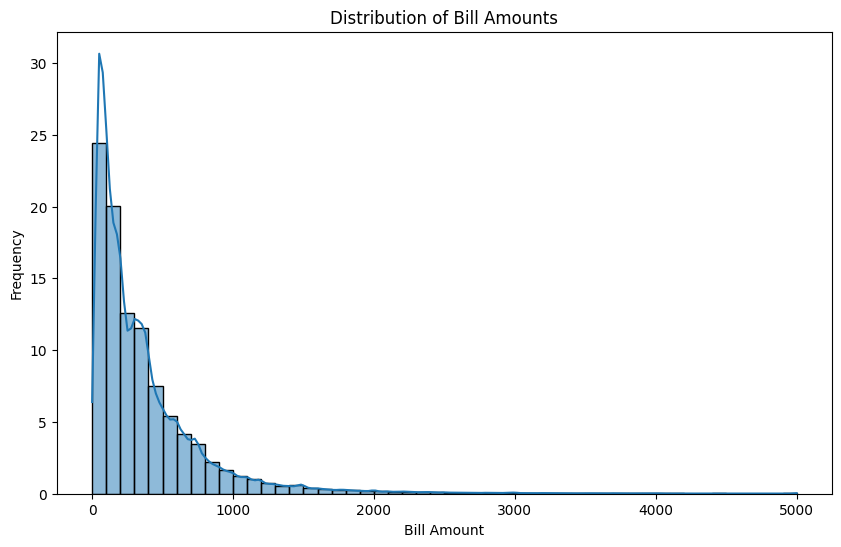

In [100]:
df3 = df_msmb[df_msmb['Bill_No'].astype(str).str.startswith(('2021','2022', '2023', '2024', '2025'))]
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.histplot(df3['Total_Bill_Amount_Corrected'], bins=50, kde=True, stat='percent')
plt.title('Distribution of Bill Amounts')
plt.xlabel('Bill Amount')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df.head()

In [121]:
def bill_amount_range_stats(df, lower, upper):
    # Subset within range
    df_range = df[(df['Total_Bill_Amount_Corrected'] >= lower) & (df['Total_Bill_Amount_Corrected'] <= upper)]
    
    # Counts
    total_count = len(df)
    range_count = len(df_range)
    count_pct = (range_count / total_count) * 100

    # Sums
    total_sum = df['Total_Bill_Amount_Corrected'].sum()
    range_sum = df_range['Total_Bill_Amount_Corrected'].sum()
    sum_pct = (range_sum / total_sum) * 100

    # Display results
    print(f"📊 Bill Amount Range: ₹{lower} to ₹{upper}")
    print(f"🧮 Count: {range_count} / {total_count} = {count_pct:.2f}%")
    print(f"💰 Sum  : ₹{range_sum:,.2f} / ₹{total_sum:,.2f} = {sum_pct:.2f}%")


bill_amount_range_stats(df, 11, 250)

📊 Bill Amount Range: ₹11 to ₹250
🧮 Count: 2337345 / 6407267 = 36.48%
💰 Sum  : ₹297,594,102.00 / ₹4,010,081,168.00 = 7.42%


BILLS CLASSIFICATION BASED ON VALUE
#11-250: Micro
#251-650: Small
#651-1650: Medium
#1651-5000: Large
#>5000: Heavy

In [103]:
#df4 = df_filtered[df_filtered['Total_Bill_Amount_Corrected'].astype(str).str.startswith(('2021','2022', '2023', '2024', '2025'))]

def classify_bill(amount):
    if 11 <= amount <= 250:
        return 'Micro'
    elif 251 <= amount <= 650:
        return 'Small'
    elif 651 <= amount <= 1650:
        return 'Medium'
    elif 1651 <= amount <= 5000:
        return 'Large'
    elif amount > 5000:
        return 'Heavy'
    else:
        return 'Unknown'

df_filtered['Bill_Class'] = df_filtered['Total_Bill_Amount_Corrected'].apply(classify_bill)
df_filtered

,Outlet,Bill_No,Total_Bill_Amount_Corrected,Bill_Item_Count,Festivity_x,z_score,Bill_Class
0,MADDILAPALEM OUTLET,2022211,280.0,1,regular,-0.031794,Small
1,MADDILAPALEM OUTLET,2022212,190.0,1,regular,-0.049230,Micro
2,MADDILAPALEM OUTLET,2022213,385.0,2,regular,-0.011452,Small
4,MADDILAPALEM OUTLET,2022218,285.0,3,regular,-0.030825,Small
7,MADDILAPALEM OUTLET,2022219,580.0,1,regular,0.026327,Small
...,...,...,...,...,...,...,...
6407254,EENADU OUTLET,202313116360,860.0,4,regular,0.080573,Medium
6407258,EENADU OUTLET,202313116361,595.0,4,regular,0.029233,Small
6407262,EENADU OUTLET,202313116362,105.0,1,regular,-0.065698,Micro
6407263,EENADU OUTLET,202313116363,418.0,2,regular,-0.005059,Small


In [105]:
df_filtered['Festivity_x'].value_counts()

Festivity_x
regular                 2964119
non-regular positive     293624
non-regular negative      65633
Name: count, dtype: int64

In [106]:
import numpy as np
import plotly.graph_objects as go

# Define data groups
df_regular = df_msmb[df_msmb['Festivity_x'].isin(['regular', 'non-regular negative'])]
df_festive = df_msmb[df_msmb['Festivity_x'] == 'non-regular positive']

# Bin settings
nbins = 25
xmin = min(df_msmb['Total_Bill_Amount_Corrected'].min(), 0)
xmax = df_msmb['Total_Bill_Amount_Corrected'].max()
bins = np.linspace(xmin, xmax, nbins + 1)

# Function to compute labeled bar plot data
def get_hist_data(data, label_color):
    counts, bin_edges = np.histogram(data['Total_Bill_Amount_Corrected'], bins=bins)
    total = counts.sum()
    percentages = (counts / total) * 100
    bin_labels = [f"{int(bin_edges[i])}–{int(bin_edges[i+1]-1)}<br>{percentages[i]:.2f}%" for i in range(len(counts))]
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    return go.Bar(
        x=bin_centers,
        y=percentages,
        text=bin_labels,
        textposition='outside',
        marker_color=label_color,
        name="",
        hovertemplate="%{text}<extra></extra>"
    )

# Define vertical lines (Micro to Heavy)
ref_lines = [
    dict(type='line', x0=250, x1=250, yref='paper', y0=0, y1=1, line=dict(color="gray", dash='dot')),
    dict(type='line', x0=650, x1=650, yref='paper', y0=0, y1=1, line=dict(color="gray", dash='dot')),
    dict(type='line', x0=1650, x1=1650, yref='paper', y0=0, y1=1, line=dict(color="gray", dash='dot')),
    dict(type='line', x0=5000, x1=5000, yref='paper', y0=0, y1=1, line=dict(color="gray", dash='dot')),
]

# Create the figure
fig = go.Figure()

# Add both groups (only one visible at a time)
fig.add_trace(get_hist_data(df_regular, 'purple'))   # visible by default
fig.add_trace(get_hist_data(df_festive, 'gold'))    # will be toggled in dropdown

# Dropdown menu to toggle traces
fig.update_layout(
    title="Bill Amount Histogram with Labels and Segments",
    template="plotly_white",
    xaxis_title="Bill Amount",
    yaxis_title="Percentage",
    xaxis=dict(tickangle=50),
    yaxis=dict(ticksuffix="%"),
    barmode='overlay',
    updatemenus=[
        dict(
            buttons=[
                dict(label="Regular + Non-Regular Negative",
                     method="update",
                     args=[{"visible": [True, False]},
                           {"title": "Bill Amounts – Regular + Non-Regular Negative"}]),
                dict(label="Non-Regular Positive (Festive)",
                     method="update",
                     args=[{"visible": [False, True]},
                           {"title": "Bill Amounts – Festive (Non-Regular Positive)"}])
            ],
            direction="down",
            showactive=True,
            x=0.5,
            xanchor="center",
            y=1.15,
            yanchor="top"
        )
    ],
    shapes=ref_lines
)

# Add segment labels
for x, label in zip([250, 650, 1650, 5000], ["Micro", "Small", "Medium", "Large"]):
    fig.add_annotation(x=x, y=95, text=label, showarrow=False, yref="paper", xanchor="right", font=dict(size=10))

fig.show()



In [108]:
dfr = df_msmb[(df_msmb['Festivity_x']=="regular") | (df_msmb['Festivity_x']=="non-regular negative")]
dfnr = df_msmb[(df_msmb['Festivity_x']=="non-regular positive")]
dfnr

,Outlet,Bill_No,Total_Bill_Amount_Corrected,Bill_Item_Count,Festivity_x,z_score
654,MADDILAPALEM OUTLET,202221130,765.0,4,non-regular positive,0.062168
658,MADDILAPALEM OUTLET,202221131,415.0,3,non-regular positive,-0.005640
661,MADDILAPALEM OUTLET,202221132,45.0,1,non-regular positive,-0.077322
662,MADDILAPALEM OUTLET,202221133,190.0,1,non-regular positive,-0.049230
663,MADDILAPALEM OUTLET,202221134,320.0,1,non-regular positive,-0.024045
...,...,...,...,...,...,...
6403000,EENADU OUTLET,202313114123,350.0,2,non-regular positive,-0.018233
6403002,EENADU OUTLET,202313114124,282.0,3,non-regular positive,-0.031407
6403005,EENADU OUTLET,202313114125,160.0,1,non-regular positive,-0.055043
6403006,EENADU OUTLET,202313114126,160.0,1,non-regular positive,-0.055043


In [111]:
df_bigbills

,Outlet,Bill_No,Total_Bill_Amount_Corrected,Bill_Item_Count,Festivity_x,z_score
5251,MADDILAPALEM OUTLET,202421741,6840.0,5,regular,1.239116
5708,MADDILAPALEM OUTLET,882024215,7100.0,12,regular,1.289488
5737,MADDILAPALEM OUTLET,2021213493,5195.0,3,regular,0.920420
6900,MADDILAPALEM OUTLET,2021214036,7050.0,3,regular,1.279801
7606,MADDILAPALEM OUTLET,2021214399,11340.0,3,regular,2.110930
...,...,...,...,...,...,...
6405424,EENADU OUTLET,202313115422,6035.0,3,regular,1.083158
6406198,EENADU OUTLET,202313115825,5400.0,3,regular,0.960136
6406286,EENADU OUTLET,202313115868,7000.0,2,regular,1.270114
6406289,EENADU OUTLET,202313115870,18500.0,3,regular,3.498082


In [122]:
bill_amount_range_stats(dfnr, 11, 250)
bill_amount_range_stats(dfr, 11, 250)
bill_amount_range_stats(dfnr, 251, 650)
bill_amount_range_stats(dfr, 251, 650)

📊 Bill Amount Range: ₹11 to ₹250
🧮 Count: 119027 / 288308 = 41.28%
💰 Sum  : ₹14,717,808.00 / ₹138,500,016.00 = 10.63%
📊 Bill Amount Range: ₹11 to ₹250
🧮 Count: 1588887 / 3020625 = 52.60%
💰 Sum  : ₹180,801,414.00 / ₹1,121,218,497.00 = 16.13%
📊 Bill Amount Range: ₹251 to ₹650
🧮 Count: 106460 / 288308 = 36.93%
💰 Sum  : ₹44,249,247.00 / ₹138,500,016.00 = 31.95%
📊 Bill Amount Range: ₹251 to ₹650
🧮 Count: 953171 / 3020625 = 31.56%
💰 Sum  : ₹393,748,579.00 / ₹1,121,218,497.00 = 35.12%


In [123]:
bill_amount_range_stats(dfnr, 651, 1650)
bill_amount_range_stats(dfr, 651, 1650)
bill_amount_range_stats(dfnr, 1650, 5000)
bill_amount_range_stats(dfr, 1650, 5000)

📊 Bill Amount Range: ₹651 to ₹1650
🧮 Count: 50579 / 288308 = 17.54%
💰 Sum  : ₹48,912,959.00 / ₹138,500,016.00 = 35.32%
📊 Bill Amount Range: ₹651 to ₹1650
🧮 Count: 400853 / 3020625 = 13.27%
💰 Sum  : ₹381,913,551.00 / ₹1,121,218,497.00 = 34.06%
📊 Bill Amount Range: ₹1650 to ₹5000
🧮 Count: 11904 / 288308 = 4.13%
💰 Sum  : ₹30,831,522.00 / ₹138,500,016.00 = 22.26%
📊 Bill Amount Range: ₹1650 to ₹5000
🧮 Count: 67954 / 3020625 = 2.25%
💰 Sum  : ₹165,900,238.00 / ₹1,121,218,497.00 = 14.80%


In [124]:
bill_amount_range_stats(dfnr, 5000, 700000)
bill_amount_range_stats(dfr, 5000, 700000)

📊 Bill Amount Range: ₹5000 to ₹700000
🧮 Count: 137 / 288308 = 0.05%
💰 Sum  : ₹685,000.00 / ₹138,500,016.00 = 0.49%
📊 Bill Amount Range: ₹5000 to ₹700000
🧮 Count: 525 / 3020625 = 0.02%
💰 Sum  : ₹2,625,000.00 / ₹1,121,218,497.00 = 0.23%


CONDITIONAL PROBABILTY BASED ON:
    
    PRODUCT - TOP 10
    FOOTFALL
    AMOUNT
    TIME OF THE DAY
    CUSTOMER

In [ ]:
from scipy.stats import zscore

# Calculate z-scores of Bill_Amount
df['z_score'] = zscore(df['Bill_Amount'])

# Keep only rows where z-score is within ±3
df1 = df[(df['z_score'] >= -3) & (df['z_score'] <= 3)]

# Optionally drop the z_score column after filtering
df1 = df1.drop(columns='z_score')

print(df1.shape)
df5 = df1[df1['Bill_No'].astype(str).str.startswith(('2022', '2023', '2024', '2025'))]

def classify_bill(amount):
    if 11 <= amount <= 250:
        return 'Micro'
    elif 251 <= amount <= 650:
        return 'Small'
    elif 651 <= amount <= 1650:
        return 'Medium'
    elif 1651 <= amount <= 5000:
        return 'Large'
    elif amount > 5000:
        return 'Heavy'
    else:
        return 'Unknown'

df5['Bill_Class'] = df5['Bill_Amount'].apply(classify_bill)
df5

(8595933, 15)


/var/folders/_n/g_d34gh57sb9jndsrxxvvdy40000gn/T/ipykernel_66003/2983613135.py:29: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Unnamed: 0,Outlet,Date,Bill_No,Item_Name,Item_Category,Item_Price,Item_Quantity,Item_Total_Amount,Daily_Bill_Amount,Total_Weight(Kg),Bill_Item_Count,Portion_Code,Festivity,Bill_Amount,Bill_Class
33,33,MADDILAPALEM OUTLET,2022-04-01,2022211,KOVA BISCUITS (ORANGE),KOVA SWEETS,266.6667,1.0,279.9967,209884.0,0.5,1,0500G,regular,280.0,Small
34,34,MADDILAPALEM OUTLET,2022-04-01,2022212,MOTHICHOOR LADDU RED,LADDUS,180.9524,1.0,190.0024,209884.0,0.5,1,0500G,regular,190.0,Micro
35,35,MADDILAPALEM OUTLET,2022-04-01,2022213,BELLAM PUTHAREKULU,HOME FOODS,128.5714,2.0,270.0029,209884.0,0.5,2,0250G,regular,385.0,Small
36,36,MADDILAPALEM OUTLET,2022-04-01,2022213,CHAMCHAM,BENGALI SYRUP ITEMS,109.5238,1.0,115.0038,209884.0,0.25,2,0250G,regular,385.0,Small
37,37,MADDILAPALEM OUTLET,2022-04-01,2022214,KAJA OIL,MAIDHA SWEETS,98.5714,1.0,103.4714,4898.0,0.25,2,0250G,regular,379.0,Small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8608006,250400,EENADU OUTLET,2024-03-31,202313116362,BOBBATLU,HOME FOODS,100.0000,1.0,105.0000,390960.0,0.25,1,0250G,regular,105.0,Micro
8608007,250401,EENADU OUTLET,2024-03-31,202313116363,KAJA OIL,MAIDHA SWEETS,361.9048,1.0,380.0048,390960.0,1.0,2,1000G,regular,418.0,Small
8608008,250402,EENADU OUTLET,2024-03-31,202313116363,WHITE KALAKAND,KALAKANDS,36.1905,1.0,38.0005,390960.0,0.05,2,0050G,regular,418.0,Small
8608009,250403,EENADU OUTLET,2024-03-31,202313116364,KAJA GHEE,MAIDHA SWEETS,138.0952,1.0,144.9952,390960.0,0.25,2,0250G,regular,335.0,Small


In [ ]:
# Ensure 'Date' is in datetime format
df5['Date'] = pd.to_datetime(df5['Date'])

# 0 = Monday, ..., 4 = Friday, 5 = Saturday, 6 = Sunday
df5['Day_Type'] = df5['Date'].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 4 else 'Weekday')
df5

/var/folders/_n/g_d34gh57sb9jndsrxxvvdy40000gn/T/ipykernel_66003/1280692247.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/_n/g_d34gh57sb9jndsrxxvvdy40000gn/T/ipykernel_66003/1280692247.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Unnamed: 0,Outlet,Date,Bill_No,Item_Name,Item_Category,Item_Price,Item_Quantity,Item_Total_Amount,Daily_Bill_Amount,Total_Weight(Kg),Bill_Item_Count,Portion_Code,Festivity,Bill_Amount,Bill_Class,Day_Type
33,33,MADDILAPALEM OUTLET,2022-04-01,2022211,KOVA BISCUITS (ORANGE),KOVA SWEETS,266.6667,1.0,279.9967,209884.0,0.5,1,0500G,regular,280.0,Small,Weekend
34,34,MADDILAPALEM OUTLET,2022-04-01,2022212,MOTHICHOOR LADDU RED,LADDUS,180.9524,1.0,190.0024,209884.0,0.5,1,0500G,regular,190.0,Micro,Weekend
35,35,MADDILAPALEM OUTLET,2022-04-01,2022213,BELLAM PUTHAREKULU,HOME FOODS,128.5714,2.0,270.0029,209884.0,0.5,2,0250G,regular,385.0,Small,Weekend
36,36,MADDILAPALEM OUTLET,2022-04-01,2022213,CHAMCHAM,BENGALI SYRUP ITEMS,109.5238,1.0,115.0038,209884.0,0.25,2,0250G,regular,385.0,Small,Weekend
37,37,MADDILAPALEM OUTLET,2022-04-01,2022214,KAJA OIL,MAIDHA SWEETS,98.5714,1.0,103.4714,4898.0,0.25,2,0250G,regular,379.0,Small,Weekend
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8608006,250400,EENADU OUTLET,2024-03-31,202313116362,BOBBATLU,HOME FOODS,100.0000,1.0,105.0000,390960.0,0.25,1,0250G,regular,105.0,Micro,Weekend
8608007,250401,EENADU OUTLET,2024-03-31,202313116363,KAJA OIL,MAIDHA SWEETS,361.9048,1.0,380.0048,390960.0,1.0,2,1000G,regular,418.0,Small,Weekend
8608008,250402,EENADU OUTLET,2024-03-31,202313116363,WHITE KALAKAND,KALAKANDS,36.1905,1.0,38.0005,390960.0,0.05,2,0050G,regular,418.0,Small,Weekend
8608009,250403,EENADU OUTLET,2024-03-31,202313116364,KAJA GHEE,MAIDHA SWEETS,138.0952,1.0,144.9952,390960.0,0.25,2,0250G,regular,335.0,Small,Weekend


In [ ]:
df5 = df5[['Outlet', 'Bill_No', 'Bill_Amount',
       'Bill_Item_Count', 'Festivity', 'Bill_Class', 'Date',
       'Total_Weight(Kg)', 'Item_Name', 'Item_Category', 'Day_Type']]
df5

,Outlet,Bill_No,Bill_Amount,Bill_Item_Count,Festivity,Bill_Class,Date,Total_Weight(Kg),Item_Name,Item_Category,Day_Type
33,MADDILAPALEM OUTLET,2022211,280.0,1,regular,Small,2022-04-01,0.5,KOVA BISCUITS (ORANGE),KOVA SWEETS,Weekend
34,MADDILAPALEM OUTLET,2022212,190.0,1,regular,Micro,2022-04-01,0.5,MOTHICHOOR LADDU RED,LADDUS,Weekend
35,MADDILAPALEM OUTLET,2022213,385.0,2,regular,Small,2022-04-01,0.5,BELLAM PUTHAREKULU,HOME FOODS,Weekend
36,MADDILAPALEM OUTLET,2022213,385.0,2,regular,Small,2022-04-01,0.25,CHAMCHAM,BENGALI SYRUP ITEMS,Weekend
37,MADDILAPALEM OUTLET,2022214,379.0,2,regular,Small,2022-04-01,0.25,KAJA OIL,MAIDHA SWEETS,Weekend
...,...,...,...,...,...,...,...,...,...,...,...
8608006,EENADU OUTLET,202313116362,105.0,1,regular,Micro,2024-03-31,0.25,BOBBATLU,HOME FOODS,Weekend
8608007,EENADU OUTLET,202313116363,418.0,2,regular,Small,2024-03-31,1.0,KAJA OIL,MAIDHA SWEETS,Weekend
8608008,EENADU OUTLET,202313116363,418.0,2,regular,Small,2024-03-31,0.05,WHITE KALAKAND,KALAKANDS,Weekend
8608009,EENADU OUTLET,202313116364,335.0,2,regular,Small,2024-03-31,0.25,KAJA GHEE,MAIDHA SWEETS,Weekend


In [ ]:
def conditional_probability(df, condition_col, condition_min=None, condition_max=None, condition_exact=None,
                            target_col=None, target_bins=None, as_percent=True):
    """
    Compute conditional probability P(target_col | condition_col).

    Parameters:
    - df: DataFrame
    - condition_col: Column to apply condition on
    - condition_min, condition_max: Lower/upper bounds for numerical condition
    - condition_exact: Use this for exact match condition (e.g., Day_Type == 'Weekend')
    - target_col: Column whose value distribution we want given the condition
    - target_bins: Optional binning (e.g., for Bill_Amount)
    - as_percent: Return percentages instead of raw counts

    Returns:
    - pandas Series (probabilities or percentages)
    """

    # Apply condition
    if condition_exact is not None:
        conditioned_df = df[df[condition_col] == condition_exact]
    elif condition_min is not None and condition_max is not None:
        conditioned_df = df[(df[condition_col] >= condition_min) & (df[condition_col] <= condition_max)]
    else:
        raise ValueError("Provide either condition_exact or both condition_min and condition_max")

    # Apply binning if needed
    if target_bins:
        target_series = pd.cut(conditioned_df[target_col], bins=target_bins)
    else:
        target_series = conditioned_df[target_col]

    result = target_series.value_counts(normalize=as_percent).sort_index()
    return result * 100 if as_percent else result


In [ ]:
conditional_probability(df5, condition_col='Day_Type', condition_exact='Weekend', target_col='Festivity')


Festivity
non-regular negative     1.871186
non-regular positive     8.262283
regular                 89.866531
Name: proportion, dtype: float64

In [ ]:
df5.drop_duplicates(subset=['Bill_No']).sample(n=5)

,Outlet,Bill_No,Bill_Amount,Bill_Item_Count,Festivity,Bill_Class,Date,Total_Weight(Kg),Item_Name,Item_Category,Day_Type
2096822,CHINAMUSRIWADA OUTLET,20222230420,328.0,2,regular,Small,2022-11-27,0.25,GULAB JAMUN,BENGALI SYRUP ITEMS,Weekend
3751814,ASILMETTA OUTLET,20231239173,90.0,1,regular,Micro,2023-10-01,-,MILK BREAD,BREADS,Weekend
1912245,KARTHIKEYA FOODS,202211100725,100.0,1,regular,Micro,2023-01-29,-,WHEAT BREAD,BREADS,Weekend
1521950,KARTHIKEYA FOODS,20221147689,155.0,2,regular,Micro,2022-08-23,-,BADAM MILK,JUICES,Weekday
2524399,NAD OUTLET,20221693833,120.0,1,regular,Micro,2023-02-19,0.1,KAJU BADAM BITE,KAJU SWEETS,Weekend


In [ ]:
df5.to_csv("/Users/anandguntuku/Movies/VSCodeFolder/SarvaniMLOps/Data/Conditional_probability_insights_input.csv")